# Лабораторная работа №2. Информативные признаки речевых сигналов: извлечение признаков.

**Цель работы**: изучение процедуры построения информативных акустических признаков для речевых сигналов.

**Краткое описание**: в рамках настоящей лабораторной работы требуется 
познакомиться с процедурами предобработки речевых сигналов и извлечения 
информативных признаков. В работе предлагается научиться извлекать 
кратковременные энергии мел-частотных полос и мел-частотные 
кепстральные коэффициенты. 

**Данные**: в качестве данных для выполнения лабораторной работы 
предлагается использовать тестовую часть базы VoxCeleb1.

___
Лабораторная работа №1 из методического пособия: Волохов В.А., Лаврентьева Г.М., Новосёлов С.А., Матвеев Ю.Н. Методические указания к выполнению лабораторных работ по курсу «Распознавание диктора». – СПб: Университет ИТМО, 2022. – 86 с.

URL: https://books.ifmo.ru/file/pdf/3087.pdf\
Вариант: id10296\
Python: 3.12.10

# import

In [29]:
import os
from pathlib import Path
import soundfile as sf
import numpy as np
from scipy.fftpack import dct
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from IPython.display import Audio, display

load_dotenv()
ROOT_PATH = Path(os.environ["ROOT_PATH"])

# 1. Подготовка данных для анализа

*Предыскажение или преэмфазис (pre-emphasis)* - это применение фильтра верхних частот к сигналу до процедуры извлечения акустических признаков.

In [30]:
DATA_PATH = ROOT_PATH / "data/id10296"

# 2. Выполнение процедуры преэмфазиса

In [31]:
speaker_id = "_BVSKK5mGnY"
wav_name = "00001.wav"
path_to_wav = DATA_PATH / f"{speaker_id}/{wav_name}"

signal, sample_rate = sf.read(path_to_wav, dtype="float32")

if signal.ndim > 1:
    signal = signal[:, 0]

signal = signal / np.abs(signal).max()

In [32]:
def preemphasis(signal, alpha=-0.97):
    """
    Процедура преэмфазиса может быть описана с помощью следующего выражения:
        y[n] = x[n] + alpha*x[n-1]
    """
    return np.append(signal[0], signal[1:] + alpha*signal[:-1])

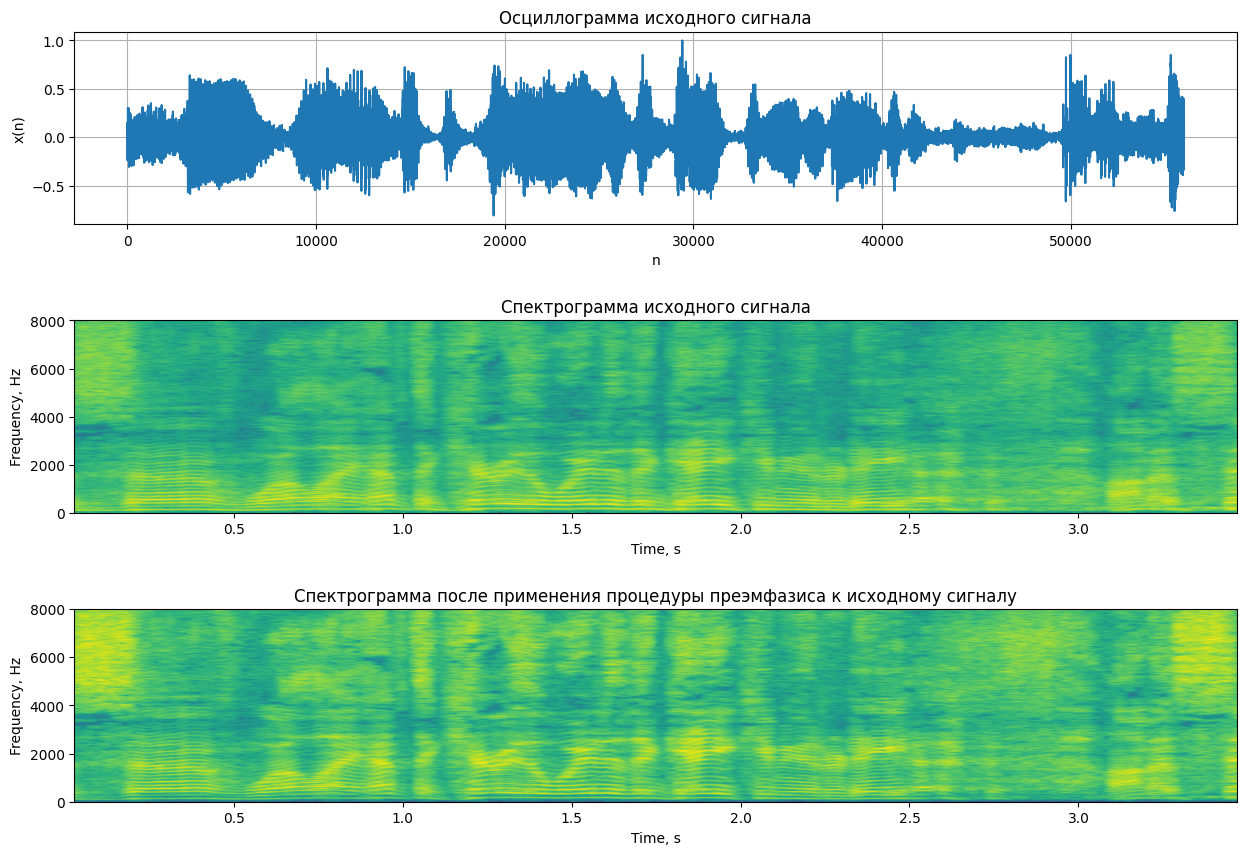

In [33]:
signal = signal[0:int(3.5 * sample_rate)] # keep the first 3.5 s 

emphasized_signal = preemphasis(signal)   # emphasized signal 
plt.figure(figsize=(15, 10)) 
plt.subplots_adjust(wspace=0, hspace=0.5) 
plot_a = plt.subplot(311) 
plot_a.plot(signal) 
plot_a.set_xlabel('n') 
plot_a.set_ylabel('x(n)') 
plot_a.title.set_text('Осциллограмма исходного сигнала') 
plot_a.grid() 
plot_b = plt.subplot(312) 
plot_b.specgram(signal, NFFT=1024, Fs=sample_rate, noverlap=900) 
plot_b.set_xlabel('Time, s') 
plot_b.set_ylabel('Frequency, Hz') 
plot_b.title.set_text('Спектрограмма исходного сигнала') 
plot_c = plt.subplot(313) 
plot_c.specgram(emphasized_signal, NFFT=1024, Fs=sample_rate, 
noverlap=900) 
plot_c.set_xlabel('Time, s') 
plot_c.set_ylabel('Frequency, Hz') 
plot_c.title.set_text('Спектрограмма после применения процедуры преэмфазиса к исходному сигналу') 
plt.show()

**Ответ**: На осциллограмме хорошо видны чередования речевых и паузовых интервалов: заметные речевые фрагменты сосредоточены примерно в промежутках 0.2-1.9 с и далее до конца анализируемого отрезка, тогда как малые амплитуды между ними соответствуют паузам или слабозвучным участкам. На спектрограмме исходного сигнала вокализованная речь проявляется как более яркие, структурированные области с выраженной гармонической организацией и устойчивыми низкочастотными формантами, а невокализованная речь выглядит как шумоподобные широкополосные участки без выраженной гармонической структуры, чаще в области высоких частот. После преэмфазиса спектрограмма становится визуально более "выровненной": низкие частоты подавляются, а высокочастотные компоненты, характерные для шумных согласных и переходных участков, становятся заметнее. Поэтому после преэмфазиса проще различать невокализованные сегменты и локальные изменения спектра, тогда как в исходной спектрограмме доминируют низкочастотные составляющие вокализованной речи.


In [34]:
display(Audio(signal, rate=sample_rate))
display(Audio(emphasized_signal, rate=sample_rate))

# 3. Вычисление акустических признаков разных видов

*Акустические признаки* являются формой представления речевого сигнала в частотно временной области. Возможным примером акустических признаков является *спектрограмма сигнала*, которую можно вычислить с использованием *оконного преобразования Фурье*. Применение спектрограммы на практике не является выгодным, в частности, из-за её большого разрешения по частоте. Поэтому возможным вариантом для построения акустических признаков могут являться: *логарифмы энергий на выходе мел-банка фильтров* (MFBs, mel filter banks), *мел-частотные кепстральные коэффициенты* (MFCCs, mel frequency cepstral coeffitients) и т.п.

В рамках настоящего пункта вычисляются логарифмы энергий на выходе мел-банка фильтров размерности 40 и мел-частотные кепстральные коэффициенты размерности 20. Для вычисления признаков можно воспользоваться следующей последовательностью действий:
1. Представить обрабатываемый речевой сигнал в виде набора фреймов (кадров) с использованием окна Хэмминга (размер окна можно выбрать равным 25 мс, а шаг окна – 10 мс);
2. Вычислить одномерный спектр Фурье и рассчитать на его основе спектр мощности по отношению к каждому из фреймов;
3. Рассчитать мел-банк фильтров;
4. Перемножить квадрат амплитудно-частотной характеристики (АЧХ) каждого фильтра со спектром мощности, который был вычислен для каждого фрейма, и просуммировать коэффициенты получившихся спектров, рассчитав энергии внутри соответствующих полос банка фильтров;
5. Вычислить логарифм от значений энергий на предыдущем шаге. На данном шаге формируется первый тип акустических признаков, то есть логарифмы энергий на выходе мел-банка фильтров;
6. Вычислить дискретное косинусное преобразование от логарифмов значений энергий. На этом этапе формируются мел-частотные кепстральные коэффициенты.

In [35]:
def framing(signal):
    frame_length = int(round(sample_rate * 0.025))
    frame_step = int(round(sample_rate * 0.01))

    signal_length = len(signal)
    if signal_length <= frame_length:
        num_frames = 1
    else:
        num_frames = int(np.ceil((signal_length - frame_length) / frame_step)) + 1

    pad_signal_length = num_frames * frame_step + frame_length
    pad_signal = np.append(signal, np.zeros(pad_signal_length - signal_length, dtype=signal.dtype))

    indices = (
        np.tile(np.arange(0, frame_length), (num_frames, 1))
        + np.tile(np.arange(0, num_frames * frame_step, frame_step), (frame_length, 1)).T
    )
    frames = pad_signal[indices.astype(np.int32, copy=False)]

    return frames * np.hamming(frame_length)


def power_spectrum(frames):
    NFFT = 512
    mag_frames = np.absolute(np.fft.rfft(frames, NFFT))
    return (1.0 / NFFT) * (mag_frames ** 2)

In [36]:
# разбиение сигнала на фреймы
frames = framing(emphasized_signal)
# вычисление спектра мощности для каждого из фреймов
pow_frames = power_spectrum(frames)

In [37]:
def compute_fbank_filters(nfilt, sample_rate, NFFT):
    low_mel = 0
    high_mel = 2595 * np.log10(1 + (sample_rate / 2) / 700)
    mel_points = np.linspace(low_mel, high_mel, nfilt + 2)
    hz_points = 700 * (10 ** (mel_points / 2595) - 1)
    bins = np.floor((NFFT + 1) * hz_points / sample_rate).astype(int)

    fbank = np.zeros((nfilt, NFFT // 2 + 1))

    for m in range(1, nfilt + 1):
        left = bins[m - 1]
        center = bins[m]
        right = bins[m + 1]

        for k in range(left, center):
            fbank[m - 1, k] = (k - left) / max(center - left, 1)

        for k in range(center, right):
            fbank[m - 1, k] = (right - k) / max(right - center, 1)

    return fbank

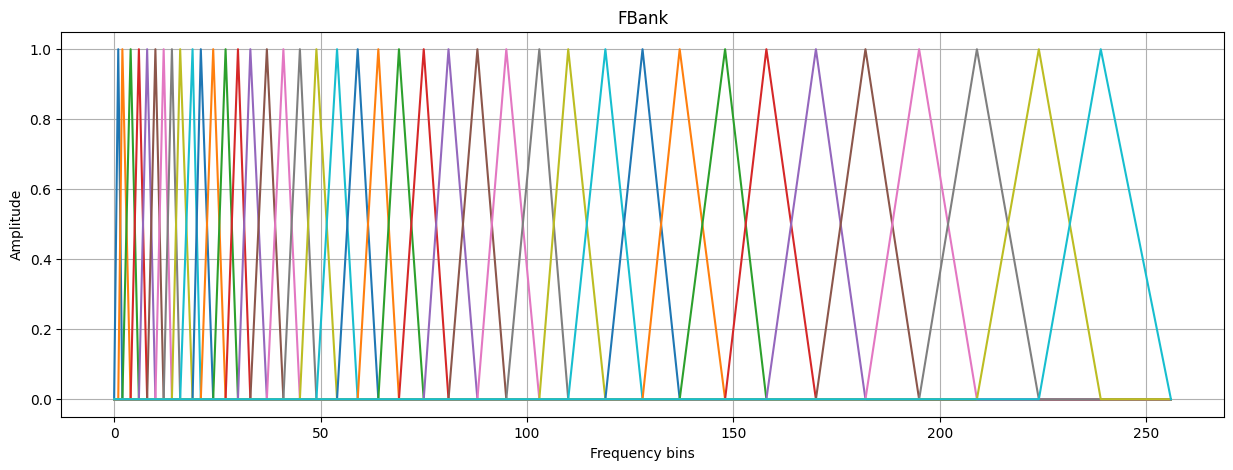

In [38]:
# синтез мел-банка фильтров
fbank = compute_fbank_filters(nfilt=40, sample_rate=16000, NFFT=512)
# визуализация квадратов АЧХ
plt.figure(figsize=(18, 8))
plot_a = plt.subplot()
plt.subplots_adjust(wspace=0, hspace=1)
nfilt = fbank.shape[0]

for k in range(nfilt):
    plot_a.plot(fbank[k,:])

plot_a.set_xlabel('Frequency bins')
plot_a.set_ylabel('Amplitude')
plot_a.title.set_text('FBank')
plot_a.grid()
plt.show()

**Ответ**: Визуализация показывает набор перекрывающихся треугольных фильтров, равномерно расположенных по мел-шкале, а не по линейной частоте. Именно поэтому в области низких частот фильтры расположены плотнее и имеют более узкую полосу, а в области высоких частот становятся шире. Такой результат соответствует свойствам слухового восприятия человека: на низких частотах слух различает изменения частоты точнее, чем на высоких. Перекрытие соседних фильтров обеспечивает плавный переход энергии между полосами и уменьшает чувствительность признаков к небольшим спектральным сдвигам.


In [39]:
def compute_fbanks_features(pow_frames, fbank):
    filter_banks = np.dot(pow_frames, fbank.T)
    filter_banks = np.maximum(filter_banks, np.finfo(float).eps)
    return np.log(filter_banks)


def compute_mfcc(filter_banks_features, num_ceps):
    mfcc = dct(filter_banks_features, type=2, axis=1, norm='ortho')
    return mfcc[:, :num_ceps]

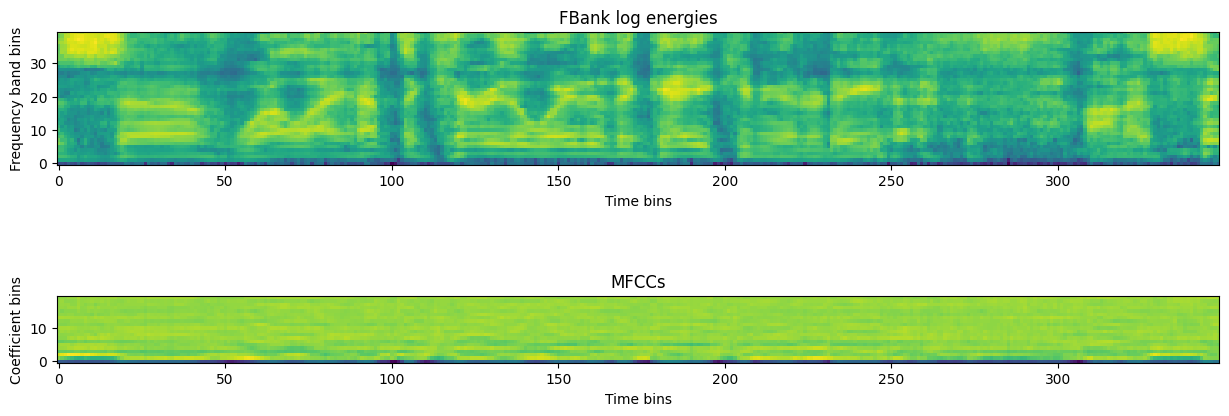

In [47]:
# вычисление логарифмов энергий на выходе мел-банка фильтров
filter_banks_features = compute_fbanks_features(pow_frames, fbank)
# вычисление мел-частотных кепстральных коэффициентов
mfcc = compute_mfcc(filter_banks_features, num_ceps=20)
# визуализация
plt.figure(figsize=(15, 5))
plt.subplots_adjust(wspace=0, hspace=0.5)
plot_a = plt.subplot(211)
plot_a.imshow(filter_banks_features.T, origin='lower')
plot_a.set_xlabel('Time bins')
plot_a.set_ylabel('Frequency band bins')
plot_a.title.set_text('FBank log energies')
plot_b = plt.subplot(212)
im = plot_b.imshow(mfcc.T, origin='lower')
plot_b.set_xlabel('Time bins')
plot_b.set_ylabel('Coefficient bins')
plot_b.title.set_text('MFCCs')
plt.show()

# 4. Выполнение локальных центрирования и масштабирования акустических признаков

Канал связи может вносить некоторое смещение в захваченный сигнал (микрофон может не иметь равномерной АЧХ, изменения в усилении сигнала приводят к вычислению различных акустических признаков даже для одного и того же куска речи). *Канальный эффект* можно промоделировать с использованием *линейного инвариантного к сдвигу фильтра* (ЛИС) и учесть при корректировке значений акустических признаков. Данная процедура получила название *процедуры нормализации*.

Идея выполнения процедуры нормализации состоит в вычислении среднего вектора наблюдаемых акустических признаков и центрирования всех векторов акустических признаков произнесения на это среднее. Процедура нормализации может быть выполнена несколькими различными способами:
1. *Локально по произнесению* (вычисление среднего в некоторой окрестности, обычно 300 фреймов, каждого фрейма стека признаков и нормализация на него этого фрейма);
2. *Глобально по произнесению* (вычисление среднего один раз по всему произнесению и нормализация на него всех фреймов этого произнесения);
3. *Глобально по базе данных* (вычисление среднего общего для всех произнесений в тренировочной базе данных и нормализация на него всех фреймов всех произнесений).

Иногда процедура нормализации сопровождается *процедурой масштабирования* акустических признаков. Процедура масштабирования признаков может быть выполнена теми же способами, что и процедура нормализации. Отличие процедуры масштабирования признаков от процедуры нормализации состоит в том, что при её выполнении необходимо вычислить не средний вектор акустических признаков, а вектор среднеквадратического отклонения, на который необходимо поэлементно разделить каждый нормализованный вектор акустических признаков некоторого произнесения.

Предполагая, что набор акустических признаков до выполнения процедур нормализации и масштабирования был задан функцией $|X(k, m)|$, а после выполнения данных процедур $|X_{norm}(k, m)|$, запишем следующее выражение:

$$|X_{norm}(k, m)|=(X(k, m) - m_X)/\sigma_X$$

где $m_X$ – это средний вектор акустических признаков, $\sigma_X$ – это вектор среднеквадратического отклонения акустических признаков, $k$ и $m$ имеют суть частоты и времени ($k$ – номер спектральной составляющей, а $m$ – это номер фрейма).

В рамках настоящего пункта выполнены локальные по произнесению процедуры нормализации и масштабирования по отношению к логарифмам энергий на выходе банка фильтров и мел-частотным кепстральным коэффициентам.

In [42]:
def mvn_floating(features, left_context, right_context):
    features = np.asarray(features, dtype=np.float32)
    num_frames, num_features = features.shape

    normalized = np.zeros_like(features)
    eps = np.finfo(np.float32).eps

    for frame_idx in range(num_frames):
        start = max(0, frame_idx - left_context)
        end = min(num_frames, frame_idx + right_context + 1)

        window = features[start:end]
        mean = np.mean(window, axis=0)
        std = np.std(window, axis=0)
        std = np.maximum(std, eps)

        normalized[frame_idx] = (features[frame_idx] - mean) / std

    return normalized

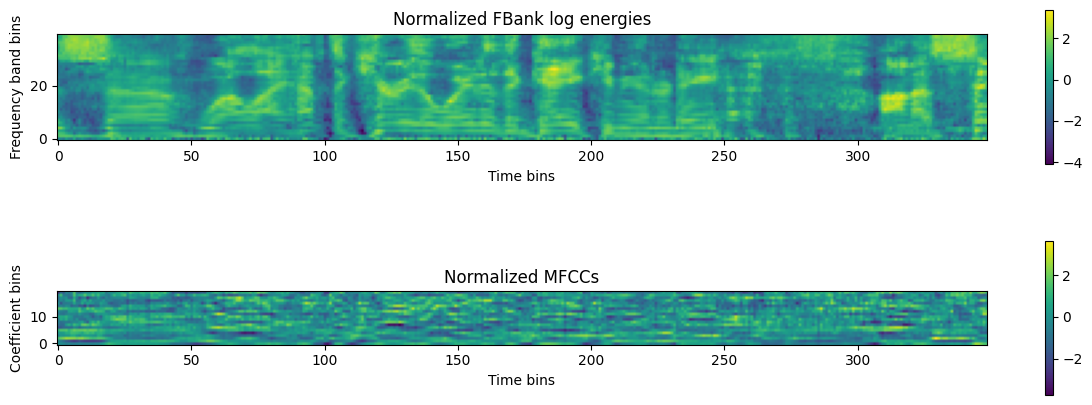

In [46]:
# вычисление нормализованных и масштабированных логарифмов энергий на выходе мел-банка фильтров
filter_banks_features_mvn = mvn_floating(filter_banks_features, 150, 150)
# вычисление нормализованных и масштабированных мел-частотных кепстральных коэффициентов
mfcc_cmvn = mvn_floating(mfcc, 150, 150)
# визуализация
fig = plt.figure(figsize=(15, 5))
plt.subplots_adjust(wspace=0, hspace=0.5)
plot_b = plt.subplot(211)
im_b = plot_b.imshow(filter_banks_features_mvn.T, origin='lower')
plt.colorbar(im_b, ax=plot_b)
plot_b.set_xlabel('Time bins')
plot_b.set_ylabel('Frequency band bins')
plot_b.title.set_text('Normalized FBank log energies')
plot_с = plt.subplot(212)
im_c = plot_с.imshow(mfcc_cmvn.T, origin='lower')
plt.colorbar(im_c, ax=plot_с)
plot_с.set_xlabel('Time bins')
plot_с.set_ylabel('Coefficient bins')
plot_с.title.set_text('Normalized MFCCs')
plt.show()

**Ответ**: В ячейке выше, показаны исходные `FBank` и `MFCC`. До локального центрирования и масштабирования яркость и динамический диапазон отдельных полос заметно зависят от общего уровня сигнала и спектрального наклона. После применения `mvn_floating` признаки становятся центрированными относительно локального среднего, а разброс по каждой компоненте приводится к сопоставимому масштабу. Визуально это выражается в более контрастной и сбалансированной картине: медленные канальные и энергетические смещения ослабляются, а локальные изменения, связанные с артикуляцией, выделяются лучше. Для `FBank` это уменьшает доминирование отдельных частотных полос, а для `MFCC` делает коэффициенты более сопоставимыми по амплитуде и удобными для дальнейшего статистического анализа и распознавания.


# 5. Построение распределений первых трёх компонент полученных акустических признаков

Для того чтобы проверить правильность расчёта акустических признаков выше, построим гистограммы распределения первых трёх компонент логарифмов энергий на выходе банка фильтров и мел-частотных кепстральных коэффициентов по некоторой базе данных. Рассмотрим в качестве этой базы звукозаписи мужских и женских голосов дикторов, список которых представлен в текстовом файле `./data/meta.txt`. В указанном файле перечислен список из 20 звукозаписей (10 для дикторов женского пола и 10 для дикторов мужского пола) из базы `VoxCeleb1`.

Используя звукозаписи, список которых перечислен в `meta.txt`, в рамках настоящего пункта выполнено построение гистограмм распределения первых 3 компонент логарифмов энергий на выходе банка фильтров и мел-частотных кепстральных коэффициентов отдельно для базы мужских и женских голосов.

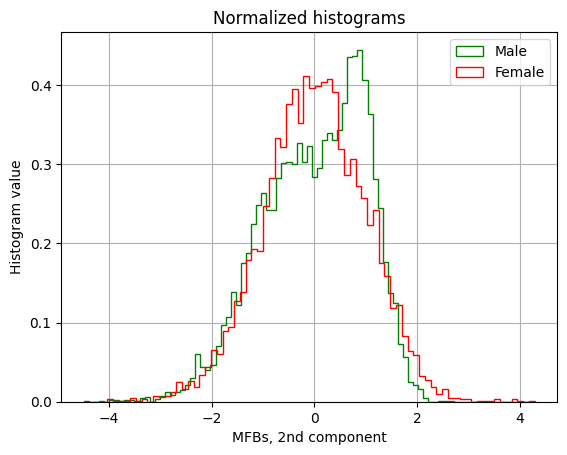

In [51]:
# построение требуемых гистограмм для первых трех компонент логарифмов энергий на выходе мел-банка фильтров и MFCC
meta_path = ROOT_PATH / "data/meta.txt"
meta_lines = [line.strip() for line in meta_path.read_text().splitlines() if line.strip()]
meta = [line.split() for line in meta_lines]
paths = [ROOT_PATH / items[0] for items in meta]
genders = [items[1] for items in meta]

fbank = compute_fbank_filters(nfilt=40, sample_rate=16000, NFFT=512)

def compute_feats(signal):
    emphasized_signal = preemphasis(signal)
    frames = framing(emphasized_signal)
    pow_frames = power_spectrum(frames)
    filter_banks_features = compute_fbanks_features(pow_frames, fbank)
    mfcc = compute_mfcc(filter_banks_features, num_ceps=20)
    return mvn_floating(filter_banks_features, 150, 150), mvn_floating(mfcc, 150, 150)

male_fb_features = []
female_fb_features = []
male_mfcc_features = []
female_mfcc_features = []

for path_to_wav, gender in zip(paths, genders):
    signal, sample_rate = sf.read(path_to_wav, dtype="float32")
    if signal.ndim > 1:
        signal = signal[:, 0]
    signal = signal / np.abs(signal).max()

    filter_banks_mvn, mfcc_cmvn = compute_feats(signal)
    if gender == 'm':
        male_fb_features.append(filter_banks_mvn)
        male_mfcc_features.append(mfcc_cmvn)
    else:
        female_fb_features.append(filter_banks_mvn)
        female_mfcc_features.append(mfcc_cmvn)

male_fb_features = np.concatenate(male_fb_features)
female_fb_features = np.concatenate(female_fb_features)
male_mfcc_features = np.concatenate(male_mfcc_features)
female_mfcc_features = np.concatenate(female_mfcc_features)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

for comp_idx in range(3):
    male_component = male_fb_features[:, comp_idx]
    female_component = female_fb_features[:, comp_idx]
    comp_min = min(male_component.min(), female_component.min())
    comp_max = max(male_component.max(), female_component.max())

    axes[comp_idx, 0].hist(male_component, int(np.sqrt(len(male_component))), histtype='step', color='green', range=(comp_min, comp_max), density=True, label='Male')
    axes[comp_idx, 0].hist(female_component, int(np.sqrt(len(female_component))), histtype='step', color='red', range=(comp_min, comp_max), density=True, label='Female')
    axes[comp_idx, 0].set_xlabel(f'FBank, component {comp_idx + 1}')
    axes[comp_idx, 0].set_ylabel('Density')
    axes[comp_idx, 0].set_title('Normalized histograms')
    axes[comp_idx, 0].legend()
    axes[comp_idx, 0].grid()

    male_component = male_mfcc_features[:, comp_idx]
    female_component = female_mfcc_features[:, comp_idx]
    comp_min = min(male_component.min(), female_component.min())
    comp_max = max(male_component.max(), female_component.max())

    axes[comp_idx, 1].hist(male_component, int(np.sqrt(len(male_component))), histtype='step', color='green', range=(comp_min, comp_max), density=True, label='Male')
    axes[comp_idx, 1].hist(female_component, int(np.sqrt(len(female_component))), histtype='step', color='red', range=(comp_min, comp_max), density=True, label='Female')
    axes[comp_idx, 1].set_xlabel(f'MFCC, component {comp_idx + 1}')
    axes[comp_idx, 1].set_ylabel('Density')
    axes[comp_idx, 1].set_title('Normalized histograms')
    axes[comp_idx, 1].legend()
    axes[comp_idx, 1].grid()

plt.show()


**Ответ**: После расширения визуализации до первых трёх компонент для `FBank` и `MFCC` видно, что распределения мужских и женских голосов после локальной нормализации и масштабирования в значительной степени перекрываются. Это ожидаемо, поскольку `CMVN/MVN` убирает постоянные энергетические и спектральные смещения, из-за чего различия между группами по первым компонентам становятся менее выраженными. Следовательно, по отдельным первым трём компонентам таких признаков надёжно детектировать пол диктора затруднительно: возможны лишь слабые статистические тенденции, но не устойчивое разделение классов. Для более уверенного различения мужских и женских голосов обычно требуется использовать многомерный набор признаков целиком, добавлять информацию о фундаментальной частоте, формантах или обучать отдельный классификатор.


# Контрольные вопросы

**Ответ**: 
1. Сигналы можно представлять во временной области, в частотной области и во временно-частотной области. Для речи это, например, осциллограмма, спектр, спектрограмма, а также компактные акустические признаки вроде `FBank`, `MFCC`, `PLP` и других параметрических описаний.
2. Спектр Фурье показывает, из каких гармонических составляющих состоит сигнал. Амплитудный спектр описывает величины этих составляющих, а фазовый спектр показывает их фазовые сдвиги относительно начала отсчёта.
3. Оконное преобразование Фурье заключается в том, что сигнал разбивают на короткие перекрывающиеся фреймы, умножают каждый фрейм на оконную функцию и для каждого окна отдельно вычисляют преобразование Фурье. Это позволяет анализировать, как спектр меняется во времени.
4. Спектрограмма — это двумерное представление сигнала, где по одной оси отложено время, по другой частота, а интенсивность цвета показывает энергию соответствующей спектральной компоненты.
5. Процедура преэмфазиса выполняется цифровым фильтром первого порядка, например по формуле `y[n] = x[n] - α x[n-1]`, где обычно `α` выбирают около `0.95-0.97`. Она усиливает высокочастотные компоненты и ослабляет спектральный наклон речевого сигнала.
6. Вычисление акустических признаков обычно включает такие шаги: чтение и нормировка сигнала, преэмфазис, разбиение на фреймы, оконное взвешивание, вычисление спектра мощности, далее в зависимости от типа признаков выполняют мел-фильтрацию, логарифмирование энергий, дискретное косинусное преобразование, вычисление дельта-признаков и другие операции. Например, `FBank` получают после мел-банка и логарифмирования, а `MFCC` — после дополнительного `DCT` от логарифмов энергий.
7. Нормализация и масштабирование акустических признаков нужны для уменьшения влияния канала, микрофона, уровня записи и медленных изменений спектра, а также для приведения компонент к сопоставимому масштабу. Это делает признаки более устойчивыми, облегчает обучение моделей и улучшает качество сравнения и классификации речевых сигналов.
